# OLED 被动膜系吸收最小化 — 生产示例

对齐 Oghma 项目 [`01_hello_oled`](../../oghma_projects/oled/01_hello_oled) 与 [`02_oled_tmm.ipynb`](02_oled_tmm.ipynb) 的 TMM 被动堆栈（ITO/Al 半平面）。

**膜系**（y=0 @ ITO）：`[ITO pad]` / ITO / NPD / Alq3 / TPBi / LiF / Al / `[Al pad]`。

**优化目标**：`minimize_total_absorptance` — 在 Oghma 反射谱波长范围、0–60° 目标网格上最小化总吸收率 A = 1 − R − T。

> 备选 cost `minimize_integrated_absorptance`：对指定层深度积分；当积分覆盖全部有限膜层时自动委托 `minimize_total_absorptance`。

**结果展示**：膜系结构（barh）、收敛曲线、优化前后吸收率及 diff。

运行前提：在 `build/` 打开；Oghma 项目与 materials root 可用（见 hello OLED notebook）。

In [ ]:
import copy
import os
import sys
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from oghma_runtime import bootstrap_tmm_session

REPO, BUILD, TMM_DIR = bootstrap_tmm_session()
import simulation

import filmstack_optimization_utils as fos
from oghma_oled_utils import (
    load_oghma_material_nk,
    load_oghma_optical_reference,
    load_oghma_project,
)
from oghma_core import _layer_role_tag, format_oghma_epitaxy_roles, preload_oghma_materials
from filmstack_optimization_utils import Polarization, StackSpec


In [2]:
from oghma_core import OghmaLayer, OghmaProject

def oghma_epitaxy_role_label(layer: OghmaLayer) -> str:
    """Short epitaxy label with Oghma Layer editor role (contact/active/other)."""
    return f"{layer.name.split()[0]}({layer.thickness_um * 1e3:g},{_layer_role_tag(layer)})"



def oled_project_material_paths(project: OghmaProject) -> list[str]:
    """Unique Oghma optical_material paths for an OLED epitaxy + contact pads."""
    paths: list[str] = []
    for layer in project.layers:
        paths.append(layer.optical_material)
    return list(dict.fromkeys(paths))





In [3]:
TOLERANCE = 0.70
OGHMA_PROJECT_DIR = REPO / "assets" / "oghma_projects" / "oled" / "01_hello_oled"
PROJECT = load_oghma_project(OGHMA_PROJECT_DIR)
REF = load_oghma_optical_reference(PROJECT)
wl_um = np.asarray(REF["reflect_wl_um"], dtype=float)
WL_UM = wl_um
VIZ_ANGLES_DEG = np.linspace(0.0, 60.0, 16)
POL = Polarization.UNPOLARIZED

TARGET_WL_LO = float(WL_UM[0])
TARGET_WL_HI = float(WL_UM[-1])
# merit 网格步长（越大 → cost 评估点数越少，优化越快）
MERIT_WL_STEP_UM = 0.02
MERIT_ANGLE_STEP_DEG = 10.0


def _layer_token(layer) -> str:
    return layer.name.split()[0].replace(":", "").replace("-", "")


from oghma_oled_utils import oled_emission_formula_from_project, oled_emission_materials_db

FORMULA = oled_emission_formula_from_project(PROJECT)
MATERIALS_DB = oled_emission_materials_db(PROJECT)
_spec_preview = fos.stack_from_formula(FORMULA, MATERIALS_DB)
layer_bounds = []
for idx in _spec_preview.film_indices:
    t0 = _spec_preview.thicknesses_um[idx]
    layer_bounds.append({
        "index": idx,
        "min": max(0.001, t0 * (1.0 - TOLERANCE)),
        "max": t0 * (1.0 + TOLERANCE),
    })

OPT_CONFIG = {
    "formula": FORMULA,
    "cost_function": {
        "path": "filmstack_optimization_utils.py",
        "name": "minimize_total_absorptance",
    },
    "polarization": "UNPOLARIZED",
    "target_wl": [TARGET_WL_LO, TARGET_WL_HI, MERIT_WL_STEP_UM],
    "target_angle": [0, 60, MERIT_ANGLE_STEP_DEG],
    "layer_bounds": layer_bounds,
    "thickness_min": 0.001,
    "thickness_max": 1.0,
    "optimizer": {
        "method": "L-BFGS-B",
        "options": {
            "maxiter": 40,
            "maxfun": 1500,
            "ftol": 1e-8,
            "gtol": 1e-8,
            "maxcor": 10,
            "maxls": 20,
            "disp": False,
        },
    },
    "multi_start": {"n_starts": 3, "seed": 42, "include_formula_x0": True},
    "dump": None,
    "verbose": True,
    "viz": {"show": ["convergence", "filmstack"]},
    "input": None,
}

from simulation_database_parser import get_simulation_database

get_simulation_database(init=True)
_OGHMA_MATERIALS = preload_oghma_materials(oled_project_material_paths(PROJECT))
print(f"preloaded {len(_OGHMA_MATERIALS)} Oghma material tables via simulation_database")
print("Oghma epitaxy:", format_oghma_epitaxy_roles(PROJECT))
print(f"λ: {wl_um[0]:.1f}–{wl_um[-1]:.1f} nm ({len(wl_um)} pts)")
print("formula:", FORMULA)
print("optimizable layers:", len(_spec_preview.film_indices))

def _oghma_spec_from_result(result):
    return fos.stack_from_formula(result["FORMULA"], MATERIALS_DB)


fos._spec_from_result = _oghma_spec_from_result


preloaded 5 Oghma material tables from /mnt/c/Users/like/oghma_local/materials
Oghma epitaxy: ITO(150,bhj) / NPD(40,lens_group) / Alq3(30,active,EML) / TPBi(30,other) / LiF(10,other) / Al(50,other)
λ: 303.5–576.5 nm (40 pts)
formula: ITO_pad 0 ITO 0.15000 NPD 0.04000 Alq3 0.03000 TPBi 0.03000 LiF 0.01000 Al 0.05000 Al_pad 0
optimizable layers: 6


In [4]:
OLED_LAYER_LABELS = (
    ["ITO pad(∞)"]
    + [oghma_epitaxy_role_label(layer) for layer in PROJECT.layers]
    + ["Al pad(∞)"]
)



def _rt_power(layers, angle_rad: float, wl_um: float):
    r_s, t_s, r_p, t_p = fos.get_r_t(layers, float(angle_rad), float(wl_um))
    return abs(r_s) ** 2, abs(t_s) ** 2, abs(r_p) ** 2, abs(t_p) ** 2


def _combine_polarization(R_s, T_s, R_p, T_p, pol: Polarization):
    if pol == Polarization.TE:
        return R_s, T_s
    if pol == Polarization.TM:
        return R_p, T_p
    return 0.5 * (R_s + R_p), 0.5 * (T_s + T_p)

def total_absorptance(layers, wl_um: float, angle_deg: float = 0.0, pol: Polarization = POL) -> float:
    th_rad = np.deg2rad(angle_deg)
    R_s, T_s, R_p, T_p = _rt_power(layers, th_rad, wl_um)
    R, T = _combine_polarization(R_s, T_s, R_p, T_p, pol)
    return float(1.0 - R - T)


def absorptance_spectrum(result, film_thicknesses_um, wl_um_grid: np.ndarray) -> np.ndarray:
    spec = fos.stack_from_formula(result["FORMULA"], MATERIALS_DB)
    x = np.asarray(film_thicknesses_um, dtype=float)
    pol = Polarization(str(result["POLARIZATION"]).upper())
    out = np.zeros(len(wl_um_grid), dtype=float)
    for i, wl in enumerate(wl_um_grid):
        layers = fos.layers_from_x(spec, x)
        out[i] = total_absorptance(layers, float(wl), angle_deg=0.0, pol=pol)
    return out


def absorptance_map(result, film_thicknesses_um, wls: np.ndarray, angles_deg: np.ndarray) -> np.ndarray:
    spec = fos.stack_from_formula(result["FORMULA"], MATERIALS_DB)
    x = np.asarray(film_thicknesses_um, dtype=float)
    pol = Polarization(str(result["POLARIZATION"]).upper())
    out = np.zeros((len(angles_deg), len(wls)), dtype=float)
    for i, ang in enumerate(angles_deg):
        for j, wl in enumerate(wls):
            layers = fos.layers_from_x(spec, x)
            out[i, j] = total_absorptance(layers, float(wl), angle_deg=float(ang), pol=pol)
    return out


def stack_thicknesses_nm(spec: StackSpec, film_thicknesses_um: np.ndarray) -> list[float]:
    thicknesses = list(spec.thicknesses_um)
    for idx, t in zip(spec.film_indices, film_thicknesses_um):
        thicknesses[idx] = float(t)
    return [t * 1000.0 for t in thicknesses]


In [5]:
def plot_oled_stack_barh(spec: StackSpec, film_thicknesses_um: np.ndarray, *, title: str):
    thicknesses_nm = stack_thicknesses_nm(spec, film_thicknesses_um)
    z = np.cumsum([0.0] + thicknesses_nm[1:-1])
    labels = OLED_LAYER_LABELS
    fig, ax = plt.subplots(figsize=(10, 1.8))
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
    for k, (z0, z1, lab) in enumerate(zip(z, z[1:], labels)):
        if z1 <= z0:
            continue
        ax.barh(0, z1 - z0, left=z0, height=0.5, color=colors[k], edgecolor="k")
        ax.text(0.5 * (z0 + z1), 0, lab, ha="center", va="center", fontsize=7)
    ax.annotate("", xy=(0, 0.35), xytext=(-30, 0.35), arrowprops=dict(arrowstyle="<-", color="gray"))
    ax.text(-15, 0.55, "ITO(∞)", ha="center", fontsize=7, color="gray")
    ax.annotate("", xy=(z[-1], 0.35), xytext=(z[-1] + 30, 0.35), arrowprops=dict(arrowstyle="->", color="gray"))
    ax.text(z[-1] + 15, 0.55, "Al(∞)", ha="center", fontsize=7, color="gray")
    ax.set_xlim(-40, z[-1] + 40)
    ax.set_yticks([])
    ax.set_xlabel("TMM depth z (nm)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_metric_1d_before_after_diff(x_nm, before, after, ylabel, title):
    diff = after - before
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(x_nm, before, label="before")
    axes[0].plot(x_nm, after, label="after")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(x_nm, diff, color="C3")
    axes[1].axhline(0, color="k", lw=0.5)
    axes[1].set_xlabel("wavelength (nm)")
    axes[1].set_ylabel(f"Δ{ylabel}")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_absorptance_map_with_diff(result, wls: np.ndarray, angles_deg: np.ndarray):
    opt = result["OPT"]
    before = absorptance_map(result, opt["initial_thicknesses_um"], wls, angles_deg)
    after = absorptance_map(result, opt["optimized_thicknesses_um"], wls, angles_deg)
    diff = after - before
    extent = [wls[0] * 1000, wls[-1] * 1000, angles_deg[0], angles_deg[-1]]
    vmin = float(min(before.min(), after.min()))
    vmax = float(max(before.max(), after.max()))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, data, lab in zip(axes, [before, after, diff], ["Before", "After", "ΔA"]):
        cmap = "viridis" if lab != "ΔA" else "RdBu_r"
        im = ax.imshow(
            data,
            extent=extent,
            aspect="auto",
            origin="lower",
            vmin=vmin if lab != "ΔA" else None,
            vmax=vmax if lab != "ΔA" else None,
            cmap=cmap,
        )
        ax.set_xlabel("λ (nm)")
        ax.set_ylabel("angle (deg)")
        ax.set_title(lab)
        plt.colorbar(im, ax=ax, label="Absorptance")
    fig.suptitle("Total absorptance A = 1 − R − T", y=1.02)
    plt.tight_layout()
    plt.show()


def print_summary(result):
    opt = result["OPT"]
    print(f"cost function: {result['COST_FUNCTION']['name']}")
    print(f"merit: {opt['merit_initial']:.6g} -> {opt['merit_final']:.6g}")
    print(f"success: {opt['success']}, message: {opt['message']}")
    init_nm = [round(t * 1000, 2) for t in opt["initial_thicknesses_um"]]
    opt_nm = [round(t * 1000, 2) for t in opt["optimized_thicknesses_um"]]
    print(f"initial  thicknesses (nm): {init_nm}")
    print(f"optimized thicknesses (nm): {opt_nm}")


def run_optimization(cfg: dict | None = None):
    cfg = copy.deepcopy(cfg or OPT_CONFIG)
    spec = fos.stack_from_formula(cfg["formula"], MATERIALS_DB)
    targets, target_wls, target_angles = fos.build_targets_from_cfg(cfg)
    pol = Polarization(str(cfg["polarization"]).upper())
    ctx = fos.make_objective_context(spec, targets, pol, cfg)
    cf = cfg["cost_function"]
    cost_fn = fos.load_filmstack_cost_function(cf["path"], cf["name"])
    x0 = np.array([spec.thicknesses_um[i] for i in spec.film_indices], dtype=float)
    merit_initial, _ = cost_fn(x0, ctx)
    opt_x, opt_result, merit_history, _ = fos._run_optimize(spec, ctx, cost_fn, cfg)
    result = fos.build_result_dict(
        cfg["formula"], spec, opt_x, targets, cf, pol, opt_result, merit_initial,
        cfg, merit_history, target_wls=target_wls, target_angles=target_angles,
    )
    return result, cfg, spec


def show_results(result, cfg, spec):
    opt = result["OPT"]
    cfg_viz = copy.deepcopy(cfg)
    cfg_viz.setdefault("viz", {})["show"] = ["convergence"]
    fos.run_filmstack_optimization_visualizations(result, cfg_viz, interactive=True)
    plot_oled_stack_barh(spec, opt["initial_thicknesses_um"], title="OLED stack — before optimization")
    plot_oled_stack_barh(spec, opt["optimized_thicknesses_um"], title="OLED stack — after optimization")
    before = absorptance_spectrum(result, opt["initial_thicknesses_um"], WL_UM)
    after = absorptance_spectrum(result, opt["optimized_thicknesses_um"], WL_UM)
    plot_metric_1d_before_after_diff(
        wl_um, before, after,
        "Absorptance A = 1 − R − T",
        f"{result['COST_FUNCTION']['name']} — absorptance vs wavelength (0°)",
    )
    plot_absorptance_map_with_diff(result, WL_UM, VIZ_ANGLES_DEG)
    print_summary(result)


py_pipe log: /tmp/simulation_plot_data_061600/py_pipe_159863.log cmd: /home/like/repos/simulation/3rdparty/infrastructure/.venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /tmp/tmpv2wm6o3m.json --HistoryManager.hist_file=:memory:


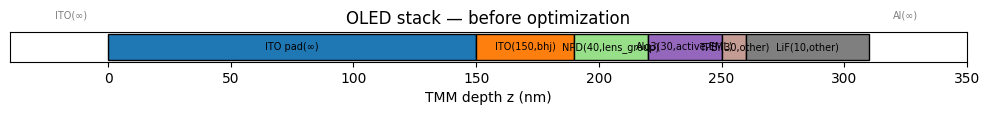

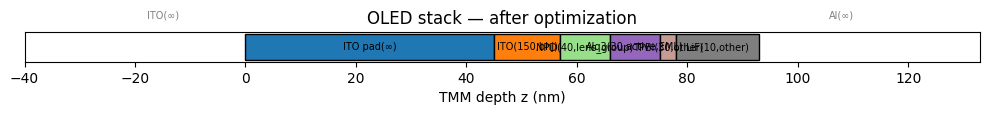

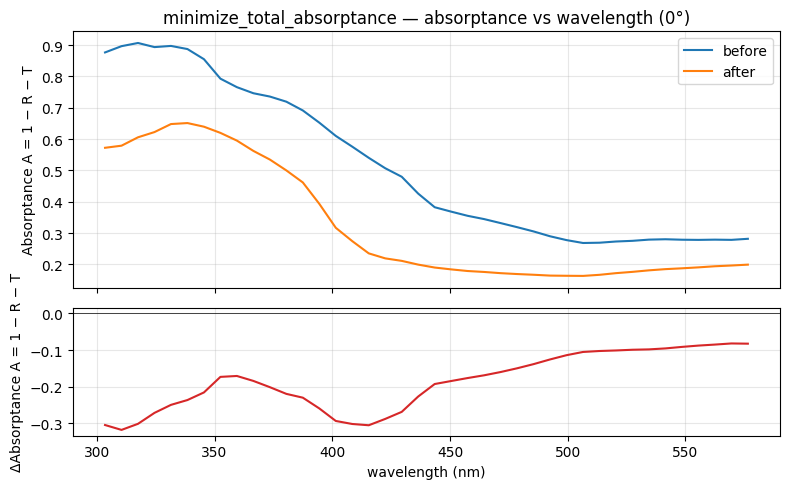

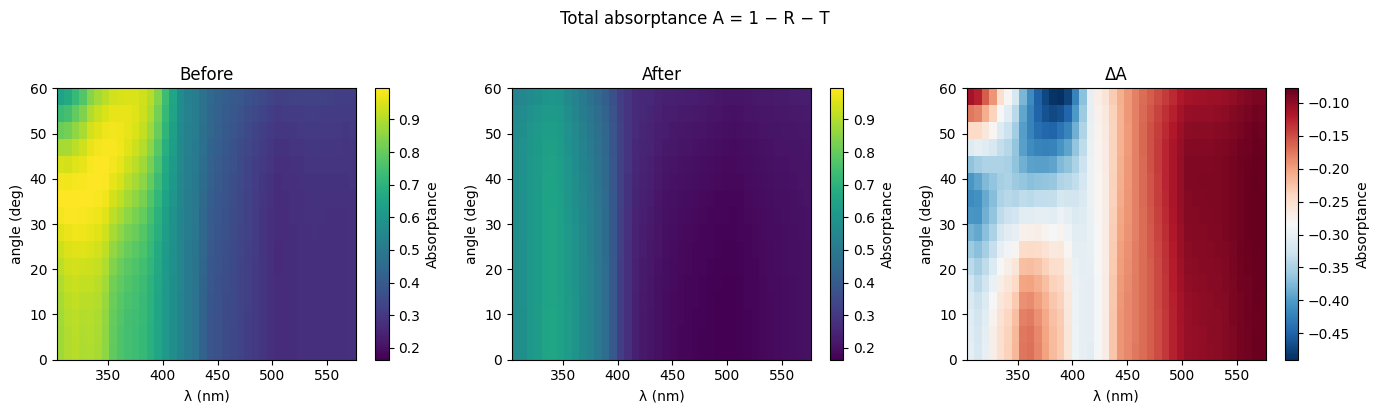

cost function: minimize_total_absorptance
merit: 0.537034 -> 0.330256
success: True, message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
initial  thicknesses (nm): [150.0, 40.0, 30.0, 30.0, 10.0, 50.0]
optimized thicknesses (nm): [45.0, 12.0, 9.0, 9.0, 3.0, 15.0]


In [6]:
result_absorb, cfg_absorb, spec_absorb = run_optimization()
show_results(result_absorb, cfg_absorb, spec_absorb)